# NBA Team Profile Scouting Demo

This notebook builds a simple coach-facing team profile using NBA team level statistics.

The goal is to move from raw NBA data to basketball interpretation.
- How good is this team overall?
- What style do they play?
- What are their strengths and weaknesses?
- What would matter in a scouting report?

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dataframe_image as dfi

from nba_api.stats.endpoints import leaguedashteamstats

## 1. Choose Team and Season

Starting with one team and season.

Later, this could become a function where a user selects any team and season from a dropdown. For now, I am just keeping it simple.

In [176]:
TEAM_NAME = "Boston Celtics"
SEASON = "2025-26"

Custom coloring and styling based on the selected team to be used on later visuals.

In [177]:
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "Arial"

TEAM_COLORS = {
    "Atlanta Hawks": {
        "primary": "#E03A3E",
        "secondary": "#C1D32F",
        "colors": {
            "red": "#E03A3E",
            "volt_green": "#C1D32F",
            "charcoal": "#26282A",
        },
    },
    "Boston Celtics": {
        "primary": "#007A33",
        "secondary": "#BA9653",
        "colors": {
            "green": "#007A33",
            "gold": "#BA9653",
            "brown": "#963821",
            "white": "#FFFFFF",
            "black": "#000000",
        },
    },
    "Brooklyn Nets": {
        "primary": "#000000",
        "secondary": "#FFFFFF",
        "colors": {
            "black": "#000000",
            "white": "#FFFFFF",
        },
    },
    "Charlotte Hornets": {
        "primary": "#1D1160",
        "secondary": "#00788C",
        "colors": {
            "purple": "#1D1160",
            "teal": "#00788C",
            "gray": "#A1A1A4",
        },
    },
    "Chicago Bulls": {
        "primary": "#CE1141",
        "secondary": "#000000",
        "colors": {
            "red": "#CE1141",
            "black": "#000000",
        },
    },
    "Cleveland Cavaliers": {
        "primary": "#860038",
        "secondary": "#FDBB30",
        "colors": {
            "wine": "#860038",
            "navy": "#041E42",
            "gold": "#FDBB30",
            "black": "#000000",
        },
    },
    "Dallas Mavericks": {
        "primary": "#00538C",
        "secondary": "#B8C4CA",
        "colors": {
            "royal_blue": "#00538C",
            "navy": "#002B5E",
            "silver": "#B8C4CA",
            "black": "#000000",
        },
    },
    "Denver Nuggets": {
        "primary": "#0E2240",
        "secondary": "#FEC524",
        "colors": {
            "midnight_blue": "#0E2240",
            "sunshine_yellow": "#FEC524",
            "flatirons_red": "#8B2131",
            "skyline_blue": "#1D428A",
        },
    },
    "Detroit Pistons": {
        "primary": "#C8102E",
        "secondary": "#1D42BA",
        "colors": {
            "red": "#C8102E",
            "royal": "#1D42BA",
            "gray": "#BEC0C2",
            "navy": "#002D62",
        },
    },
    "Golden State Warriors": {
        "primary": "#1D428A",
        "secondary": "#FFC72C",
        "colors": {
            "blue": "#1D428A",
            "gold": "#FFC72C",
        },
    },
    "Houston Rockets": {
        "primary": "#CE1141",
        "secondary": "#000000",
        "colors": {
            "red": "#CE1141",
            "black": "#000000",
            "silver": "#C4CED4",
        },
    },
    "Indiana Pacers": {
        "primary": "#002D62",
        "secondary": "#FDBB30",
        "colors": {
            "blue": "#002D62",
            "yellow": "#FDBB30",
            "silver": "#BEC0C2",
        },
    },
    "Los Angeles Clippers": {
        "primary": "#C8102E",
        "secondary": "#1D428A",
        "colors": {
            "red": "#C8102E",
            "blue": "#1D428A",
            "silver": "#BEC0C2",
            "black": "#000000",
        },
    },
    "Los Angeles Lakers": {
        "primary": "#552583",
        "secondary": "#FDB927",
        "colors": {
            "purple": "#552583",
            "gold": "#FDB927",
            "black": "#000000",
        },
    },
    "Memphis Grizzlies": {
        "primary": "#5D76A9",
        "secondary": "#12173F",
        "colors": {
            "blue": "#5D76A9",
            "navy": "#12173F",
            "yellow": "#F5B112",
            "gray": "#707271",
        },
    },
    "Miami Heat": {
        "primary": "#98002E",
        "secondary": "#F9A01B",
        "colors": {
            "red": "#98002E",
            "yellow": "#F9A01B",
            "black": "#000000",
        },
    },
    "Milwaukee Bucks": {
        "primary": "#00471B",
        "secondary": "#EEE1C6",
        "colors": {
            "green": "#00471B",
            "cream": "#EEE1C6",
            "blue": "#0077C0",
            "black": "#000000",
        },
    },
    "Minnesota Timberwolves": {
        "primary": "#0C2340",
        "secondary": "#78BE20",
        "colors": {
            "midnight_blue": "#0C2340",
            "lake_blue": "#236192",
            "moonlight_grey": "#9EA2A2",
            "aurora_green": "#78BE20",
        },
    },
    "New Orleans Pelicans": {
        "primary": "#0C2340",
        "secondary": "#C8102E",
        "colors": {
            "navy": "#0C2340",
            "red": "#C8102E",
            "gold": "#85714D",
        },
    },
    "New York Knicks": {
        "primary": "#006BB6",
        "secondary": "#F58426",
        "colors": {
            "blue": "#006BB6",
            "orange": "#F58426",
            "silver": "#BEC0C2",
            "black": "#000000",
        },
    },
    "Oklahoma City Thunder": {
        "primary": "#007AC1",
        "secondary": "#EF3B24",
        "colors": {
            "blue": "#007AC1",
            "sunset": "#EF3B24",
            "navy": "#002D62",
            "yellow": "#FDBB30",
        },
    },
    "Orlando Magic": {
        "primary": "#0077C0",
        "secondary": "#C4CED4",
        "colors": {
            "blue": "#0077C0",
            "silver": "#C4CED4",
            "black": "#000000",
        },
    },
    "Philadelphia 76ers": {
        "primary": "#006BB6",
        "secondary": "#ED174C",
        "colors": {
            "blue": "#006BB6",
            "red": "#ED174C",
            "navy": "#002B5C",
            "silver": "#C4CED4",
        },
    },
    "Phoenix Suns": {
        "primary": "#1D1160",
        "secondary": "#E56020",
        "colors": {
            "purple": "#1D1160",
            "orange": "#E56020",
            "black": "#000000",
            "gray": "#63727A",
            "yellow": "#F9AD1B",
        },
    },
    "Portland Trail Blazers": {
        "primary": "#E03A3E",
        "secondary": "#000000",
        "colors": {
            "red": "#E03A3E",
            "black": "#000000",
        },
    },
    "Sacramento Kings": {
        "primary": "#5A2D81",
        "secondary": "#63727A",
        "colors": {
            "purple": "#5A2D81",
            "gray": "#63727A",
            "black": "#000000",
        },
    },
    "San Antonio Spurs": {
        "primary": "#C4CED4",
        "secondary": "#000000",
        "colors": {
            "silver": "#C4CED4",
            "black": "#000000",
        },
    },
    "Toronto Raptors": {
        "primary": "#CE1141",
        "secondary": "#000000",
        "colors": {
            "red": "#CE1141",
            "black": "#000000",
            "silver": "#A1A1A4",
            "gold": "#B4975A",
        },
    },
    "Utah Jazz": {
        "primary": "#002B5C",
        "secondary": "#F9A01B",
        "colors": {
            "navy": "#002B5C",
            "green": "#00471B",
            "yellow": "#F9A01B",
        },
    },
    "Washington Wizards": {
        "primary": "#002B5C",
        "secondary": "#E31837",
        "colors": {
            "navy": "#002B5C",
            "red": "#E31837",
            "silver": "#C4CED4",
        },
    },
}

team_theme = TEAM_COLORS.get(
    TEAM_NAME,
    {"primary": "#1F2937", "secondary": "#9CA3AF", "colors": {}}
)

PRIMARY = team_theme["primary"]
SECONDARY = team_theme["secondary"]
NEUTRAL = "#A1A1AA"
BG = "#F8FAFC"
TEXT = "#111827"
GRID = "#E5E7EB"

## 2. Pull Team Advanced Stats

Using 'nba_api', which accesses NBA.com stats endpoints.

The advanced team table gives useful coach-facing stats:
- Offensive Rating
- Defensive Rating
- Net Rating
- Pace
- Effective Field Goal Percentage
- True Shooting Percentage
- Turnover Percentage
- Rebounding Percentages

These are better for team profile work than raw points per game because they account for pace, efficiency, and more.

In [178]:
advanced_stats = leaguedashteamstats.LeagueDashTeamStats(
    season = SEASON,
    measure_type_detailed_defense = "Advanced",
    per_mode_detailed = "Per100Possessions"
)
advanced_df = advanced_stats.get_data_frames()[0]
advanced_df.head(10)

,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,E_OFF_RATING,OFF_RATING,E_DEF_RATING,...,AST_TO_RANK,AST_RATIO_RANK,OREB_PCT_RANK,DREB_PCT_RANK,REB_PCT_RANK,TM_TOV_PCT_RANK,EFG_PCT_RANK,TS_PCT_RANK,PACE_RANK,PIE_RANK
0,1610612737,Atlanta Hawks,82,46,36,0.561,3951.0,113.2,115.0,111.0,...,3,2,20,9,17,8,10,12,5,14
1,1610612738,Boston Celtics,82,56,26,0.683,3946.0,116.8,120.0,109.7,...,9,22,5,6,3,3,11,13,30,4
2,1610612751,Brooklyn Nets,82,20,62,0.244,3951.0,105.8,108.2,116.0,...,29,20,21,22,27,29,30,30,26,29
3,1610612766,Charlotte Hornets,82,44,38,0.537,3951.0,114.7,118.4,111.9,...,23,16,2,2,2,28,12,10,27,10
4,1610612741,Chicago Bulls,82,31,51,0.378,3951.0,110.5,112.1,115.1,...,13,8,26,7,16,21,14,16,3,21
5,1610612739,Cleveland Cavaliers,82,52,30,0.634,3951.0,116.3,118.3,111.9,...,7,6,9,18,10,9,5,6,13,9
6,1610612742,Dallas Mavericks,82,26,56,0.317,3971.0,108.5,110.3,113.9,...,22,24,27,10,18,13,28,28,4,23
7,1610612743,Denver Nuggets,82,54,28,0.659,3986.0,119.4,121.2,114.7,...,1,3,22,3,8,2,1,1,20,7
8,1610612765,Detroit Pistons,82,60,22,0.732,3961.0,114.3,117.3,106.6,...,16,13,3,20,4,23,15,14,19,2
9,1610612744,Golden State Warriors,82,37,45,0.451,3961.0,112.0,113.8,112.6,...,15,4,13,24,24,26,13,11,18,19


## 3. Clean the Data

This step will help make the dataframe more readable.

In [179]:
team_df = advanced_df.copy()

team_df.columns = (
    team_df.columns
    .str.lower()
    .str.replace(" ", "_")
)

team_df.head(10)

,team_id,team_name,gp,w,l,w_pct,min,e_off_rating,off_rating,e_def_rating,...,ast_to_rank,ast_ratio_rank,oreb_pct_rank,dreb_pct_rank,reb_pct_rank,tm_tov_pct_rank,efg_pct_rank,ts_pct_rank,pace_rank,pie_rank
0,1610612737,Atlanta Hawks,82,46,36,0.561,3951.0,113.2,115.0,111.0,...,3,2,20,9,17,8,10,12,5,14
1,1610612738,Boston Celtics,82,56,26,0.683,3946.0,116.8,120.0,109.7,...,9,22,5,6,3,3,11,13,30,4
2,1610612751,Brooklyn Nets,82,20,62,0.244,3951.0,105.8,108.2,116.0,...,29,20,21,22,27,29,30,30,26,29
3,1610612766,Charlotte Hornets,82,44,38,0.537,3951.0,114.7,118.4,111.9,...,23,16,2,2,2,28,12,10,27,10
4,1610612741,Chicago Bulls,82,31,51,0.378,3951.0,110.5,112.1,115.1,...,13,8,26,7,16,21,14,16,3,21
5,1610612739,Cleveland Cavaliers,82,52,30,0.634,3951.0,116.3,118.3,111.9,...,7,6,9,18,10,9,5,6,13,9
6,1610612742,Dallas Mavericks,82,26,56,0.317,3971.0,108.5,110.3,113.9,...,22,24,27,10,18,13,28,28,4,23
7,1610612743,Denver Nuggets,82,54,28,0.659,3986.0,119.4,121.2,114.7,...,1,3,22,3,8,2,1,1,20,7
8,1610612765,Detroit Pistons,82,60,22,0.732,3961.0,114.3,117.3,106.6,...,16,13,3,20,4,23,15,14,19,2
9,1610612744,Golden State Warriors,82,37,45,0.451,3961.0,112.0,113.8,112.6,...,15,4,13,24,24,26,13,11,18,19


## 4. Select Coach Facing Metrics

Obviously do not need or want every column.

For an inital team profile I will focus on:
- Overall quality: offensive rating, defensive rating, & net rating
- Style: pace
- Shot efficiency: effective field goal percentage & true shooting percentage
- Possession control: turnover percentage
- Rebounding: offensive and defensive rebounding percentages

In [180]:
profile_cols = [
    "team_name",
    "gp",
    "w",
    "l",
    "w_pct",
    "off_rating",
    "def_rating",
    "net_rating",
    "pace",
    "efg_pct",
    "ts_pct",
    "tm_tov_pct",
    "oreb_pct",
    "dreb_pct",
    "reb_pct"
]
profile_df = team_df[profile_cols].copy()
profile_df.head()

,team_name,gp,w,l,w_pct,off_rating,def_rating,net_rating,pace,efg_pct,ts_pct,tm_tov_pct,oreb_pct,dreb_pct,reb_pct
0,Atlanta Hawks,82,46,36,0.561,115.0,112.9,2.2,102.50,0.554,0.584,0.138,0.291,0.702,0.495
1,Boston Celtics,82,56,26,0.683,120.0,111.7,8.3,95.58,0.553,0.583,0.129,0.336,0.710,0.525
2,Brooklyn Nets,82,20,62,0.244,108.2,118.2,-10.0,97.60,0.520,0.559,0.161,0.287,0.687,0.478
3,Charlotte Hornets,82,44,38,0.537,118.4,113.5,4.9,97.59,0.552,0.589,0.157,0.358,0.722,0.539
4,Chicago Bulls,82,31,51,0.378,112.1,117.4,-5.3,103.22,0.547,0.580,0.148,0.279,0.708,0.496


## 5. Add League Rankings

Raw values need context.

A 117 offensive rating means much more when we know whether that ranks 2nd, 13th, or 28th in the league.

For most stats, higher is better. For defensive rating and turnover percentage, lower is better.

In [181]:
rank_rules = {
    "off_rating": False,
    "def_rating": True,
    "net_rating": False,
    "pace": False,
    "efg_pct": False,
    "ts_pct": False,
    "tm_tov_pct": True,
    "oreb_pct": False,
    "dreb_pct": False,
    "reb_pct": False
}
for col, ascending in rank_rules.items():
    profile_df[f"{col}_rank"] = profile_df[col].rank(
        ascending=ascending,
        method="min"
    ).astype(int)

profile_df.head(10)

,team_name,gp,w,l,w_pct,off_rating,def_rating,net_rating,pace,efg_pct,...,off_rating_rank,def_rating_rank,net_rating_rank,pace_rank,efg_pct_rank,ts_pct_rank,tm_tov_pct_rank,oreb_pct_rank,dreb_pct_rank,reb_pct_rank
0,Atlanta Hawks,82,46,36,0.561,115.0,112.9,2.2,102.50,0.554,...,14,9,12,5,10,11,8,20,9,17
1,Boston Celtics,82,56,26,0.683,120.0,111.7,8.3,95.58,0.553,...,2,4,4,30,11,13,3,5,5,3
2,Brooklyn Nets,82,20,62,0.244,108.2,118.2,-10.0,97.60,0.520,...,30,25,29,26,30,30,29,21,22,27
3,Charlotte Hornets,82,44,38,0.537,118.4,113.5,4.9,97.59,0.552,...,5,11,8,27,12,9,27,2,2,2
4,Chicago Bulls,82,31,51,0.378,112.1,117.4,-5.3,103.22,0.547,...,25,22,23,3,14,16,20,26,7,15
5,Cleveland Cavaliers,82,52,30,0.634,118.3,114.1,4.1,100.70,0.561,...,6,15,9,13,4,5,8,9,18,10
6,Dallas Mavericks,82,26,56,0.317,110.3,115.5,-5.2,102.62,0.527,...,27,19,22,4,27,28,13,26,9,18
7,Denver Nuggets,82,54,28,0.659,121.2,116.0,5.2,99.49,0.577,...,1,21,7,20,1,1,2,22,3,8
8,Detroit Pistons,82,60,22,0.732,117.3,108.9,8.4,99.88,0.546,...,9,2,2,19,15,13,23,3,20,4
9,Golden State Warriors,82,37,45,0.451,113.8,114.4,-0.5,100.05,0.549,...,19,16,20,18,13,11,26,13,24,22


## 6. Create a Single Team Profile

Now will fitler to our selected team. 

This row is the foundation for the scouting summary.

In [182]:
selected_team = profile_df.loc[profile_df["team_name"] == TEAM_NAME].copy()
selected_team

team_profile = selected_team.iloc[0].to_dict()
team_profile

{'team_name': 'Boston Celtics',
 'gp': 82,
 'w': 56,
 'l': 26,
 'w_pct': 0.683,
 'off_rating': 120.0,
 'def_rating': 111.7,
 'net_rating': 8.3,
 'pace': 95.58,
 'efg_pct': 0.553,
 'ts_pct': 0.583,
 'tm_tov_pct': 0.129,
 'oreb_pct': 0.336,
 'dreb_pct': 0.71,
 'reb_pct': 0.525,
 'off_rating_rank': 2,
 'def_rating_rank': 4,
 'net_rating_rank': 4,
 'pace_rank': 30,
 'efg_pct_rank': 11,
 'ts_pct_rank': 13,
 'tm_tov_pct_rank': 3,
 'oreb_pct_rank': 5,
 'dreb_pct_rank': 5,
 'reb_pct_rank': 3}

## 7. Compare to League Average

Scouting reports need comparison.

Instead of saying a teams raw shooting percentage, we want to know whether that is above or below league average.

In [183]:
league_avg = profile_df[
    [
        "off_rating",
        "def_rating",
        "net_rating",
        "pace",
        "efg_pct",
        "ts_pct",
        "tm_tov_pct",
        "oreb_pct",
        "dreb_pct",
        "reb_pct"
    ]
].mean()
league_avg

comparison_metircs = [
    "off_rating",
    "def_rating",
    "net_rating",
    "pace",
    "efg_pct",
    "ts_pct",
    "tm_tov_pct",
    "oreb_pct",
    "dreb_pct",
    "reb_pct"
]
comparison_rows = []
for metric in comparison_metircs:
    team_value = team_profile[metric]
    avg_value = league_avg[metric]
    diff = team_value - avg_value
    comparison_rows.append({
        "metric": metric,
        "team_value": team_value,
        "league_average": avg_value,
        "difference": diff,
        "rank": team_profile[f"{metric}_rank"]
    })
comparison_df = pd.DataFrame(comparison_rows)
comparison_df

comparison_df["team_value"] = comparison_df["team_value"].round(3)
comparison_df["league_average"] = comparison_df["league_average"].round(3)
comparison_df["difference"] = comparison_df["difference"].round(3)
comparison_df

,metric,team_value,league_average,difference,rank
0,off_rating,120.000,114.787,5.213,2
1,def_rating,111.700,114.733,-3.033,4
2,net_rating,8.300,0.053,8.247,4
3,pace,95.580,100.217,-4.637,30
4,efg_pct,0.553,0.546,0.007,11
5,ts_pct,0.583,0.581,0.002,13
6,tm_tov_pct,0.129,0.144,-0.015,3
7,oreb_pct,0.336,0.305,0.031,5
8,dreb_pct,0.710,0.695,0.015,5
9,reb_pct,0.525,0.500,0.025,3


## 8. Visualize Key Team Traits

The first visual compares the selected team to league average.

This is useful for a coach-facing report as it quickly shows where a team seperates from the league.

In [184]:
chart_metrics = ["efg_pct", "tm_tov_pct", "oreb_pct", "dreb_pct"]
chart_df = comparison_df[comparison_df["metric"].isin(chart_metrics)].copy()
chart_df = chart_df.reset_index(drop=True)
chart_df

metric_labels = {
    "efg_pct": "eFG%",
    "tm_tov_pct": "TOV%",
    "oreb_pct": "ORB%",
    "dreb_pct": "DRB%"
}
chart_df["label"] = chart_df["metric"].map(metric_labels)
chart_df["team_pct"] = chart_df["team_value"]*100
chart_df["league_pct"] = chart_df["league_average"]*100
chart_df["diff_pct_points"] = chart_df["team_pct"] - chart_df["league_pct"]
chart_df


,metric,team_value,league_average,difference,rank,label,team_pct,league_pct,diff_pct_points
0,efg_pct,0.553,0.546,0.007,11,eFG%,55.3,54.6,0.7
1,tm_tov_pct,0.129,0.144,-0.015,3,TOV%,12.9,14.4,-1.5
2,oreb_pct,0.336,0.305,0.031,5,ORB%,33.6,30.5,3.1
3,dreb_pct,0.710,0.695,0.015,5,DRB%,71.0,69.5,1.5


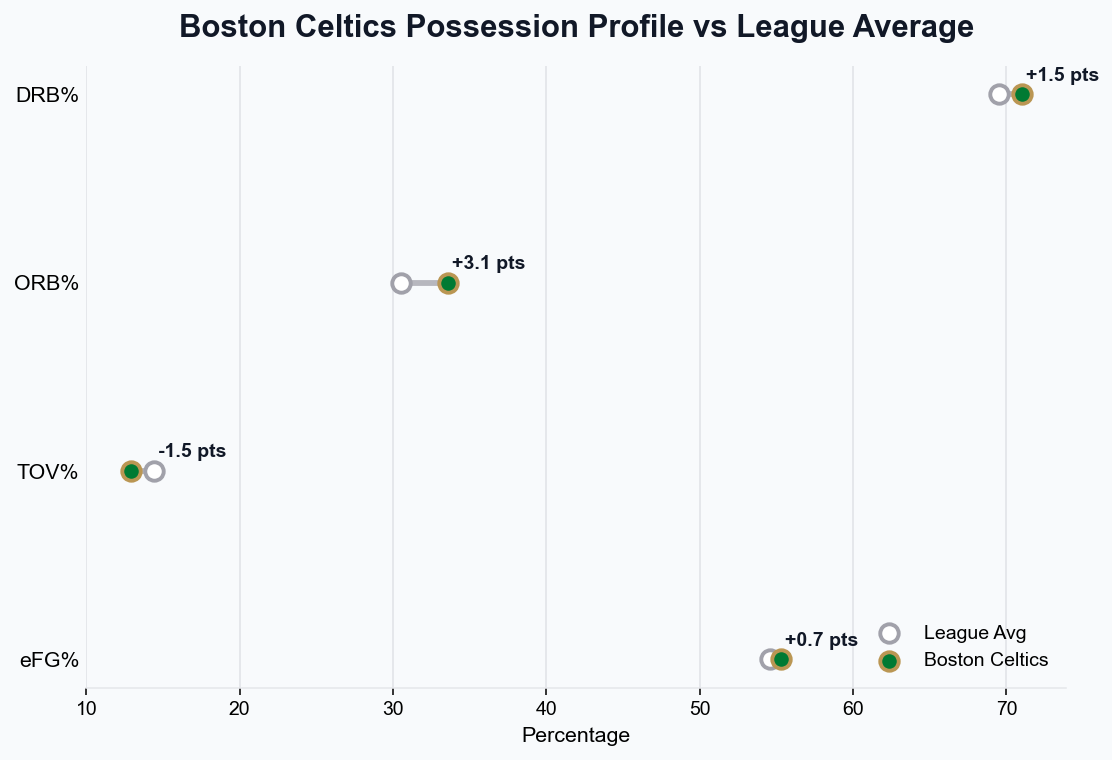

In [185]:
y = np.arange(len(chart_df))

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.hlines(
    y=y,
    xmin=chart_df["league_pct"],
    xmax=chart_df["team_pct"],
    color=NEUTRAL,
    linewidth=3,
    alpha=0.75
)
ax.scatter(
    chart_df["league_pct"],
    y,
    s=90,
    color="white",
    edgecolor=NEUTRAL,
    linewidth=2,
    label="League Avg",
    zorder=3
)
ax.scatter(
    chart_df["team_pct"],
    y,
    s=90,
    color=PRIMARY,
    edgecolor=SECONDARY,
    linewidth=2,
    label=TEAM_NAME,
    zorder=4
)

for i, row in chart_df.iterrows():
    diff = row["diff_pct_points"]
    sign = "+" if diff >= 0 else ""
    ax.text(
        max(row["team_pct"], row["league_pct"]) + 0.25,
        i+0.1,
        f"{sign}{diff:.1f} pts",
        va="center",
        fontsize=10,
        color=TEXT,
        fontweight="bold"
    )

ax.set_yticks(y)
ax.set_yticklabels(chart_df["label"], fontsize=11)
ax.set_xlabel("Percentage", fontsize=11)
ax.set_title(
    f"{TEAM_NAME} Possession Profile vs League Average",
    fontsize=16,
    fontweight="bold",
    color=TEXT,
    pad=15
)
ax.grid(axis="x", color=GRID, linewidth=1)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(axis="y", length=0)
ax.legend(frameon=False, loc="lower right")

plt.subplots_adjust(left=0.18, right=0.88, top=0.86, bottom=0.12)
plt.show()

## 9. League Context Scatter Plot

This chart shows where the selected team sits compared to the rest of the league.

Teams want to be towards the right side offensively and lower defensively. A strong team usually has a high offensive rating and low defensive rating.

/var/folders/d7/0nc_nxfn1cvcn2ddb3w51mfw0000gn/T/ipykernel_13129/2651473884.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


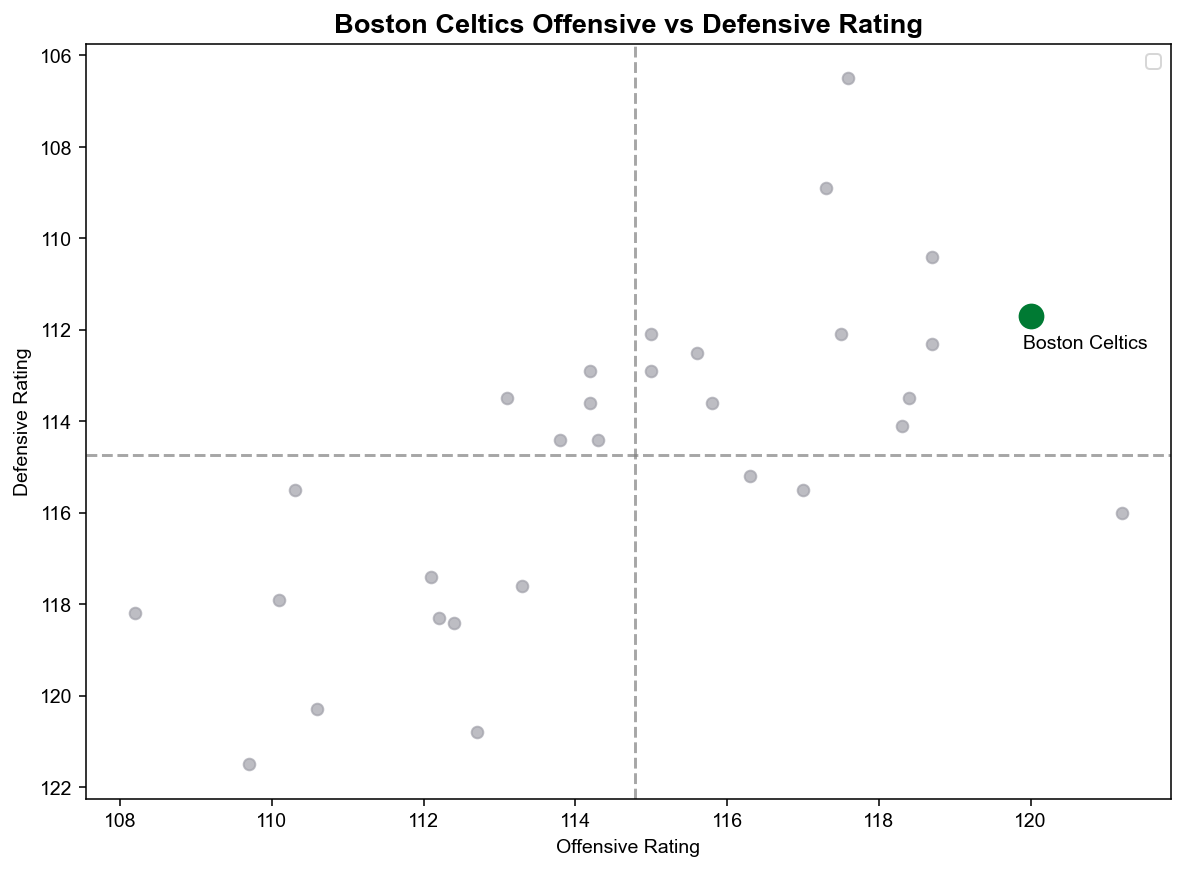

In [186]:
fig, ax = plt.subplots(figsize = (10,7))

ax.scatter(
    profile_df["off_rating"],
    profile_df["def_rating"],
    alpha=0.7,
    color=NEUTRAL
)
selected = profile_df[profile_df["team_name"] == TEAM_NAME].iloc[0]
avg_off_rating = profile_df["off_rating"].mean()
avg_def_rating = profile_df["def_rating"].mean()
ax.axvline(
    avg_off_rating,
    linestyle = "--",
    color = "gray",
    alpha = 0.7
)
ax.axhline(
    avg_def_rating,
    linestyle = "--",
    color = "gray",
    alpha = 0.7
)
ax.scatter(
    selected["off_rating"],
    selected["def_rating"],
    s=150,
    color = PRIMARY
)
ax.text(
    selected["off_rating"]-0.1,
    selected["def_rating"]+0.7,
    TEAM_NAME,
    fontsize=10,
    color="black"
)
ax.set_title(f"{TEAM_NAME} Offensive vs Defensive Rating", fontsize=14, fontweight="bold")
ax.set_xlabel("Offensive Rating")
ax.set_ylabel("Defensive Rating")
ax.invert_yaxis()
ax.legend()
plt.show()

## 10. Turn Stats Into Basketball Language

A good basketball analytics project does not stop at just numbers. It translates numbers into useful basketball interpretation. 

In [187]:
def describe_rank(rank):
    if rank <= 5:
        return "Elite"
    elif rank <= 10:
        return "Top-Third"
    elif rank <= 20:
        return "Middle-Third"
    elif rank <= 25: 
        return "Bottom-Third"
    else:
        return "Very Poor"
    
offense_tier = describe_rank(team_profile["off_rating_rank"])
defense_tier = describe_rank(team_profile["def_rating_rank"])
pace_tier = describe_rank(team_profile["pace_rank"])
efg_tier = describe_rank(team_profile["efg_pct_rank"])
turnover_tier = describe_rank(team_profile["tm_tov_pct_rank"])
oreb_tier = describe_rank(team_profile["oreb_pct_rank"])
dreb_tier = describe_rank(team_profile["dreb_pct_rank"])
team_profile

{'team_name': 'Boston Celtics',
 'gp': 82,
 'w': 56,
 'l': 26,
 'w_pct': 0.683,
 'off_rating': 120.0,
 'def_rating': 111.7,
 'net_rating': 8.3,
 'pace': 95.58,
 'efg_pct': 0.553,
 'ts_pct': 0.583,
 'tm_tov_pct': 0.129,
 'oreb_pct': 0.336,
 'dreb_pct': 0.71,
 'reb_pct': 0.525,
 'off_rating_rank': 2,
 'def_rating_rank': 4,
 'net_rating_rank': 4,
 'pace_rank': 30,
 'efg_pct_rank': 11,
 'ts_pct_rank': 13,
 'tm_tov_pct_rank': 3,
 'oreb_pct_rank': 5,
 'dreb_pct_rank': 5,
 'reb_pct_rank': 3}

In [188]:

tier_dict = {
    "ORTG": offense_tier,
    "DRTG": defense_tier,
    "Pace": pace_tier,
    "eFG": efg_tier,
    "TOV": turnover_tier,
    "ORB": oreb_tier,
    "DRB": dreb_tier
}
tier_df = pd.DataFrame({
    "Metric":tier_dict.keys(),
    "Value":[team_profile["off_rating"], team_profile["def_rating"], team_profile["pace"], team_profile["efg_pct"], team_profile["tm_tov_pct"], team_profile["oreb_pct"], team_profile["dreb_pct"]],
    "Rank": [team_profile["off_rating_rank"], team_profile["def_rating_rank"], team_profile["pace_rank"], team_profile["efg_pct_rank"], team_profile["tm_tov_pct_rank"], team_profile["oreb_pct_rank"], team_profile["dreb_pct_rank"]],
    "Profile": tier_dict.values()
})
tier_df

,Metric,Value,Rank,Profile
0,ORTG,120.000,2,Elite
1,DRTG,111.700,4,Elite
2,Pace,95.580,30,Very Poor
3,eFG,0.553,11,Middle-Third
4,TOV,0.129,3,Elite
5,ORB,0.336,5,Elite
6,DRB,0.710,5,Elite


In [ ]:
def profile_color(value):
    colors = {
        "Elite": f"background-color: {PRIMARY}; color: white;",
        "Strong": f"background-color: {SECONDARY}; color: #111827;",
        "Average": "background-color: #E5E7EB; color: #111827;",
        "Very Poor": "background-color: #FDE68A; color: #111827;",
        "Weak": "background-color: #FCA5A5; color: #111827;",
        "Very Fast": f"background-color: {PRIMARY}; color: white;",
        "Fast": f"background-color: {SECONDARY}; color: #111827;",
        "Middle-Third": "background-color: #E5E7EB; color: #111827;",
        "Slow": "background-color: #DBEAFE; color: #111827;",
        "Very Slow": "background-color: #BFDBFE; color: #111827;",
    }
    return colors.get(value, "")
tier_df["Value"] = np.where(
    tier_df["Value"] <= 1,
    tier_df["Value"]*100,
    tier_df["Value"]
)
tier_df["Value"] = tier_df["Value"].round(1)
tier_df

CELTICS_LOGO_URL = "https://upload.wikimedia.org/wikipedia/en/thumb/8/8f/Boston_Celtics.svg/250px-Boston_Celtics.svg.png"

styled_tier_df = (
    tier_df.style
    .hide(axis="index")
    .set_caption(
        f"""
        <div class="table-title">
            <img src="{CELTICS_LOGO_URL}" class="team-logo">
            <span>{TEAM_NAME} Team Profile Snapshot</span>
        </div>
        """
    )
    .format({
        "Value": "{:.1f}",
        "Rank": "#{:.0f}"
    })
    .map(profile_color, subset=["Profile"])
    .set_properties(
        subset=["Value", "Rank"],
        **{"text-align":"center",}
    )
    .set_properties(
        subset=["Metric"],
        **{
            "text-align": "left",
            "font-weight": "700",
            "border-right": "2px solid #111827",
        }
    )
    .set_properties(
        subset=["Profile"],
        **{
            "text-align": "right",
            "font-weight": "600",
            "border-left": "2px solid #111827",
        }
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", NEUTRAL),
                ("color", "white"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("text-align", "center"),
            ],
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("padding", "0 0 18px 0"),
            ],
        },
        {
            "selector": ".table-title",
            "props": [
                ("display", "flex"),
                ("align-items", "center"),
                ("justify-content", "center"),
                ("gap", "14px"),
                ("font-size", "24px"),
                ("font-weight", "800"),
                ("color", "#111827"),
                ("text-align", "center"),
            ],
        },
        {
            "selector": ".team-logo",
            "props": [
                ("width", "42px"),
                ("height", "42px"),
                ("object-fit", "contain"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "10px"),
                ("border-bottom", "1px solid #E5E7EB"),
            ],
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("font-family", "Arial"),
                ("font-size", "14px"),
                ("width", "700px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [
                ("border-right", "2px solid #111827"),
            ],
        },
        {
            "selector": "th.col3",
            "props": [
                ("border-left", "2px solid #111827"),
            ],
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("font-family", "Arial, sans-serif"),
                ("font-size", "18px"),
                ("width", "900px"),
                ("margin", "0 auto"),
            ],
        },
    ])
)

styled_tier_df
#dfi.export(styled_tier_df, "test.png", table_conversion="chrome")